In [54]:
from cmath import acosh

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [23]:
df = pd.read_csv("fifa_eda.csv")
display(df.head())
df.info(memory_usage="deep")

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     17955 non-null  float64
 8   Wage                      18207 non-null  float64
 9   Preferred Foot            18207 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Skill Moves               18159 non-null  float64
 12  Position                  18207 non-null  object 
 13  Joined                    18207 non-null  int64  
 14  Contra

In [24]:
miss_data = df.isnull().sum()
miss_data[miss_data > 0]

Club                        241
Value                       252
International Reputation     48
Skill Moves                  48
Contract Valid Until        289
dtype: int64

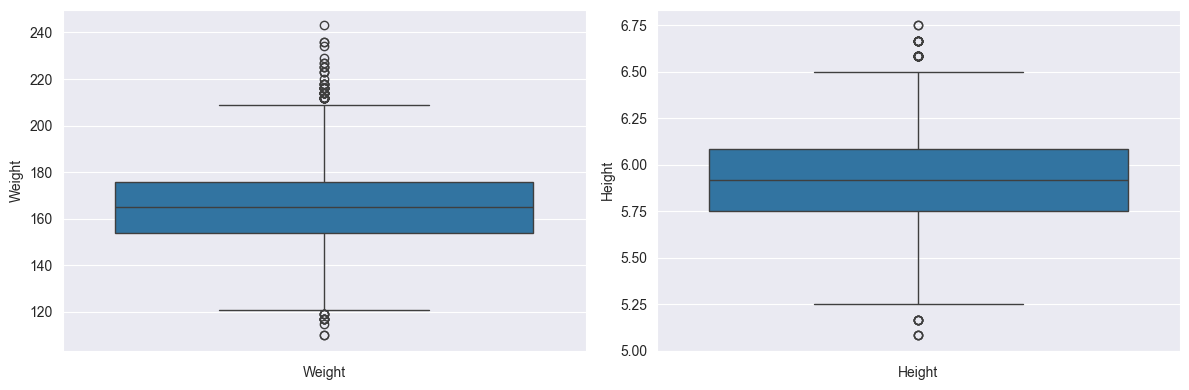

In [43]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
sns.boxplot(y=df['Weight'], ax=ax[0])
ax[0].set_xlabel('Weight')

sns.boxplot(y=df['Height'], ax=ax[1])
ax[1].set_xlabel('Height')

plt.tight_layout()
plt.show()

In [45]:
df['Joined'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 18207 entries, 0 to 18206
Series name: Joined
Non-Null Count  Dtype
--------------  -----
18207 non-null  int64
dtypes: int64(1)
memory usage: 142.4 KB


In [52]:
df['Joined'] = pd.to_datetime(df['Joined'])
df['Joined'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 18207 entries, 0 to 18206
Series name: Joined
Non-Null Count  Dtype         
--------------  -----         
18207 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 142.4 KB


In [64]:
cols = ['Value', 'Wage', 'Release Clause']
(df[cols] < 0).sum()

Value             0
Wage              0
Release Clause    0
dtype: int64

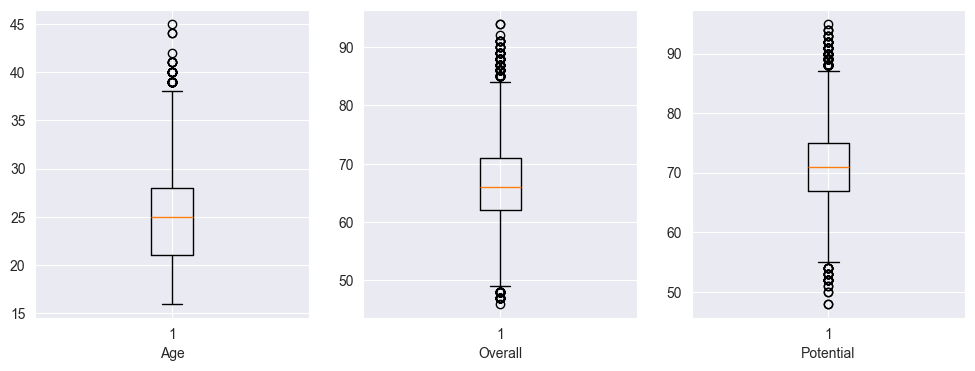

In [68]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

ax[0].boxplot(df['Age'])
ax[0].set_xlabel('Age')

ax[1].boxplot(df['Overall'])
ax[1].set_xlabel('Overall')

ax[2].boxplot(df['Potential'])
ax[2].set_xlabel('Potential')

plt.show()

In [69]:
df['Age'].describe()

count    18207.000000
mean        25.122206
std          4.669943
min         16.000000
25%         21.000000
50%         25.000000
75%         28.000000
max         45.000000
Name: Age, dtype: float64

In [71]:
most_popular = df['Nationality'].value_counts()
most_popular.sort_values(ascending=False)[:10]

Nationality
England        1662
Germany        1198
Spain          1072
Argentina       937
France          914
Brazil          827
Italy           702
Colombia        618
Japan           478
Netherlands     453
Name: count, dtype: int64

In [103]:
left_foot = df[df['Preferred Foot']=='Left'].value_counts().sum()
pre_left_foot = df.shape[0] / left_foot
print("Players with left foot: ", pre_left_foot.round(1), '%')

Players with left foot:  4.4 %


In [96]:
df.groupby('Position')['Preferred Foot'].count().sort_values(ascending=False)

Position
ST     2154
GK     2027
CB     1779
CM     1395
LB     1372
RB     1291
RM     1127
LM     1095
CAM     959
CDM     948
RCB     662
LCB     648
LCM     395
RCM     391
LW      381
RW      370
RDM     248
LDM     243
LS      207
RS      203
RWB      87
LWB      78
CF       74
LAM      21
RAM      21
RF       16
LF       15
Name: Preferred Foot, dtype: int64

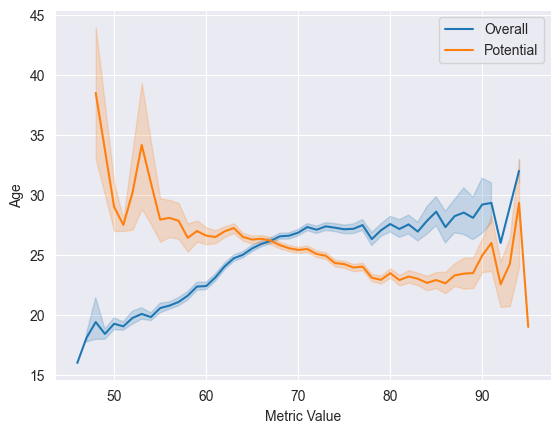

In [107]:
sns.lineplot(data=df, x='Overall', y='Age', label='Overall')
sns.lineplot(data=df, x='Potential', y='Age', label='Potential')

plt.xlabel('Metric Value')
plt.legend()
plt.show()

In [109]:
age_stats = df.groupby('Age')[['Overall', 'Potential']].mean()
age_stats['Difference'] = age_stats['Potential'] - age_stats['Overall']
peak_age = age_stats['Difference'].idxmin()

min_diff = age_stats['Difference'].min()

print(f"Піковий вік гравців: {peak_age} років")
print(f"Середня різниця між Potential та Overall у цьому віці: {min_diff:.2f}")

Піковий вік гравців: 31 років
Середня різниця між Potential та Overall у цьому віці: 0.00


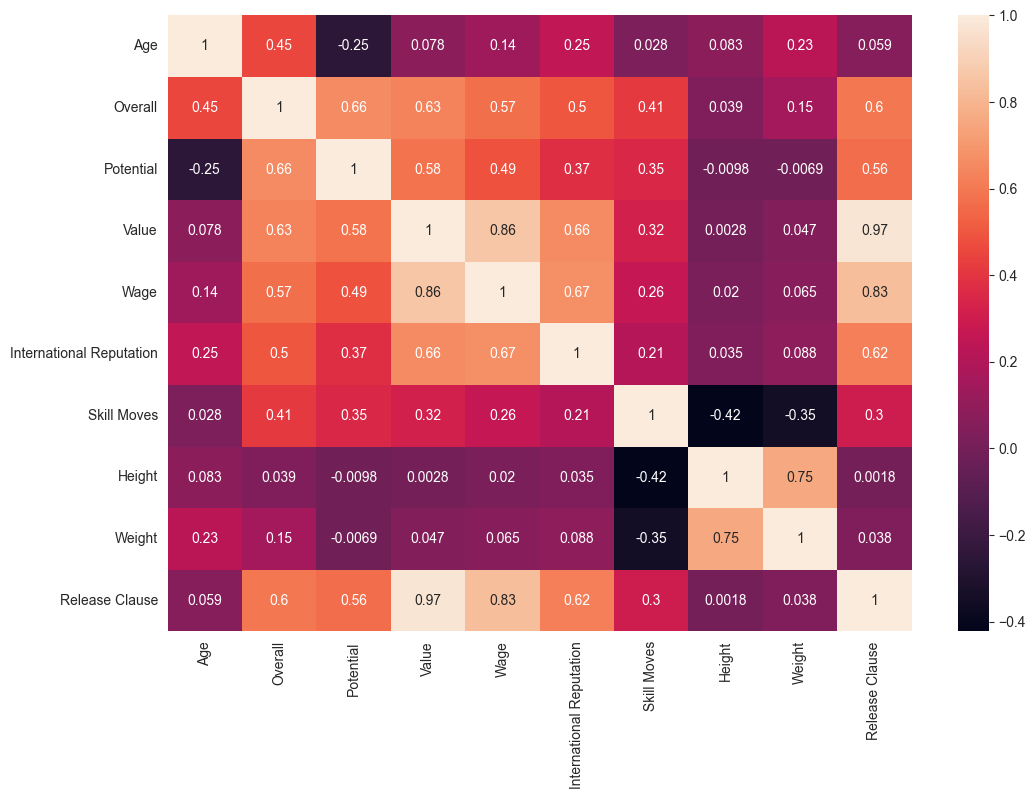

In [116]:
corr_data = df.select_dtypes([np.number]).drop('ID',axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_data, annot=True)
plt.show()

In [118]:
corr_data[:5]

,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Height,Weight,Release Clause
Age,1.000000,0.452350,-0.253312,0.078315,0.141145,0.253765,0.027649,0.082506,0.229940,0.058672
Overall,0.452350,1.000000,0.660939,0.631848,0.571926,0.499491,0.414463,0.038527,0.154557,0.597821
Potential,-0.253312,0.660939,1.000000,0.579608,0.486413,0.372993,0.354290,-0.009791,-0.006935,0.562346
Value,0.078315,0.631848,0.579608,1.000000,0.858086,0.656158,0.317246,0.002827,0.046702,0.973310
Wage,0.141145,0.571926,0.486413,0.858086,1.000000,0.668635,0.263205,0.019638,0.064764,0.828161


In [125]:
top_5_clubs = df.groupby('Club')['Value'].mean().sort_values(ascending=False).head().reset_index()
top_5_clubs['Value'] = top_5_clubs['Value'].apply(lambda x: f"€{x:,.2f}")
print("Топ-5 клубів за середньою вартістю гравців:")
print(top_5_clubs)

Топ-5 клубів за середньою вартістю гравців:
                Club       Value
0           Juventus  €28,179.00
1        Real Madrid  €26,497.73
2       FC Barcelona  €25,836.36
3    Manchester City  €23,835.00
4  FC Bayern München  €23,414.66


In [134]:
nation_stats = df.groupby('Nationality')['Overall'].agg(
    player_count='count',
    avg_overall='mean'
)

filtered_nations = nation_stats[nation_stats['player_count'] >= 20]
filtered_nations.head()

,player_count,avg_overall
Nationality,,
Albania,40,65.925000
Algeria,60,70.633333
Argentina,937,68.572038
Australia,236,62.652542
Austria,298,64.916107
